# 🏠 Real Estate Price Prediction — Ames Housing Dataset

**Author:** Shivam Singh  
**Dataset:** Ames Housing Dataset (2,930 records, 82 features)  
**Objective:** Build a robust machine learning pipeline to predict residential property sale prices using structural, qualitative, and locational features.

---

## 📋 Project Overview

This notebook walks through a complete end-to-end machine learning pipeline:

1. **Data Loading & Initial Inspection** — Understanding the dataset structure
2. **Missing Value Handling** — Imputing numerical and categorical columns strategically
3. **Outlier Detection & Treatment** — IQR-based capping for continuous and discrete variables
4. **Categorical Feature Cleaning** — Rare category grouping, spelling corrections
5. **Variable Transformation** — Log1p and Yeo-Johnson to reduce skewness
6. **Encoding** — Binary, Ordinal, and One-Hot encoding based on variable type
7. **Multicollinearity Check** — VIF analysis and feature pruning
8. **Correlation Analysis** — Identifying high-impact predictors of SalePrice
9. **Feature Scaling** — StandardScaler and RobustScaler tailored per feature
10. **Exploratory Data Analysis (EDA)** — Heatmaps, scatter plots, residual analysis
11. **Model Training & Evaluation** — Simple LR, Multiple LR, Ridge, Lasso, Random Forest
12. **Final Comparison** — Selecting the best model based on test-set performance


---
## 1. Importing Libraries and Loading the Dataset

All required libraries are imported at the top of the notebook to maintain a clean, single-flow structure.  
This avoids redundant re-imports in later cells and keeps dependencies clearly visible to any reviewer.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


### Loading the Raw Dataset

The Ames Housing dataset is loaded into a Pandas DataFrame.  
We inspect its shape, data types, and descriptive statistics to get an initial understanding of the data.


In [6]:
# Load the raw dataset
df = pd.read_csv('Original_raw_dataset_AmesHousing.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows   : {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset Shape: (2930, 82)
Total Rows   : 2930
Total Columns: 82


**What we did:** Loaded the CSV file into a DataFrame.  
**What we got:** A dataset with 2,930 rows and 82 columns covering a wide range of residential property features.


In [7]:
# Preview the first 5 rows
display(df.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [8]:
# Display column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [9]:
# Descriptive statistics for all numerical columns
display(df.describe())

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


**Observations:**  
- The dataset contains a mix of numerical (integer/float) and categorical (object) columns.  
- Several columns have fewer non-null values than the total row count, indicating missing data.  
- Descriptive statistics reveal wide value ranges in area-related features (e.g., `Lot Area`, `Gr Liv Area`), suggesting potential outliers.


---
## 2. Missing Value Analysis and Treatment

Before any preprocessing, we identify all columns with missing values, visualize their percentage, and apply an appropriate imputation or dropping strategy.


In [10]:
# Count and sort missing values per column (descending)
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

display(missing_summary)

,Missing Count,Missing (%)
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


**What we did:** Calculated the absolute count and percentage of missing values per column.  
**What we got:** Several columns exceed 60% missingness — these are too sparse to be useful for modeling.


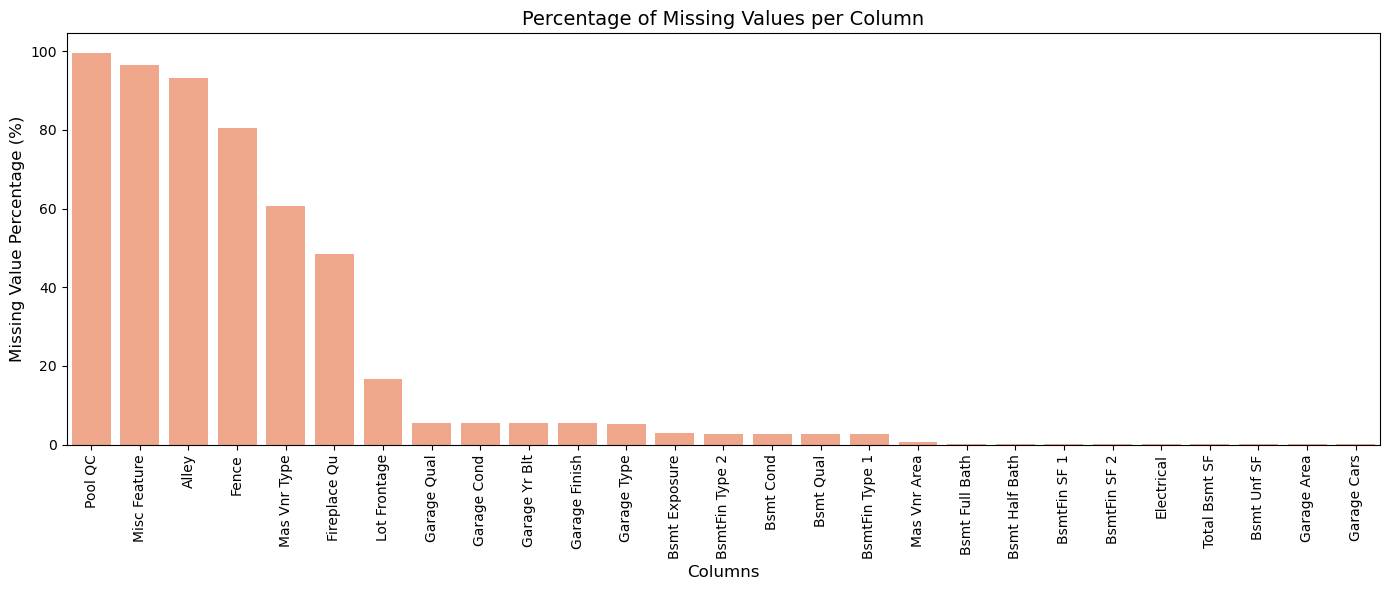

In [11]:
# Visualize missing value percentage across all affected columns
missing_pct_filtered = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=missing_pct_filtered.index, y=missing_pct_filtered, color='lightsalmon')
plt.xticks(rotation=90)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Missing Value Percentage (%)", fontsize=12)
plt.title("Percentage of Missing Values per Column", fontsize=14)
plt.tight_layout()
plt.show()

### 2.1 Dropping High-Missingness Columns (> 60%)

Columns with more than 60% missing values are dropped because imputing them would introduce significant noise and bias into the model.

| Column         | Missing % | Reason for Dropping       |
|----------------|-----------|---------------------------|
| Pool QC        | ~99%      | Extremely sparse           |
| Misc Feature   | ~97%      | Extremely sparse           |
| Alley          | ~93%      | Extremely sparse           |
| Fence          | ~80%      | Majority missing           |
| Mas Vnr Type   | ~64%      | High sparsity              |


In [12]:
# Drop columns with more than 60% missing values
columns_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type']
df_dropped = df.drop(columns=columns_to_drop)

print(f"Shape after dropping high-missingness columns: {df_dropped.shape}")

Shape after dropping high-missingness columns: (2930, 77)


### 2.2 Imputing Missing Values in Numerical Columns

For each remaining numerical column with missing values, we apply a logically appropriate imputation strategy.

**Strategy:**
- `Lot Frontage` → **Median** (missingness does not imply zero frontage; median is a robust estimator)
- All garage, basement, and masonry area columns → **0** (missingness indicates absence of that structural feature)


In [13]:
# Impute 'Lot Frontage' with median
df_dropped['Lot Frontage'] = df_dropped['Lot Frontage'].fillna(df_dropped['Lot Frontage'].median())

# Impute absence-indicating columns with 0
zero_impute_cols = [
    'Garage Yr Blt', 'Mas Vnr Area', 'Bsmt Half Bath', 'Bsmt Full Bath',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Total Bsmt SF', 'Bsmt Unf SF',
    'Garage Cars', 'Garage Area'
]

for col in zero_impute_cols:
    df_dropped[col] = df_dropped[col].fillna(0)

# Verify — no missing values should remain in these columns
print("Remaining missing values in imputed numerical columns:")
print(df_dropped[zero_impute_cols + ['Lot Frontage']].isnull().sum())

Remaining missing values in imputed numerical columns:
Garage Yr Blt     0
Mas Vnr Area      0
Bsmt Half Bath    0
Bsmt Full Bath    0
BsmtFin SF 1      0
BsmtFin SF 2      0
Total Bsmt SF     0
Bsmt Unf SF       0
Garage Cars       0
Garage Area       0
Lot Frontage      0
dtype: int64


**What we did:** Applied median imputation to `Lot Frontage` and zero-fill to all structural absence columns.  
**What we got:** All targeted numerical columns now have zero missing values.


### 2.3 Imputing Missing Values in Categorical Columns

Categorical columns are handled differently based on the nature of their missingness:

- **Structural absence columns** (Fireplace Qu, Garage Cond, Garage Qual, Garage Finish, Garage Type, Bsmt Exposure, BsmtFin Type 1/2, Bsmt Cond, Bsmt Qual) → Filled with **'None'** (absence of the feature)
- **Electrical** → Filled with **Mode** ('SBrkr') because every house must have an electrical system


In [14]:
# Fill absence-indicating categorical columns with 'None'
categorical_none_cols = [
    'Fireplace Qu', 'Garage Cond', 'Garage Qual', 'Garage Finish',
    'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2', 'Bsmt Cond',
    'Bsmt Qual', 'BsmtFin Type 1'
]

for col in categorical_none_cols:
    df_dropped[col] = df_dropped[col].fillna('None')

# Fill 'Electrical' with mode (every house must have electricity)
electrical_mode = df_dropped['Electrical'].mode()[0]
df_dropped['Electrical'] = df_dropped['Electrical'].fillna(electrical_mode)

# Final check — total missing values
total_missing = df_dropped.isnull().sum().sum()
print(f"Total missing values remaining in the DataFrame: {total_missing}")

Total missing values remaining in the DataFrame: 0


**What we did:** Applied 'None' imputation to structural absence columns and mode imputation to `Electrical`.  
**What we got:** The dataset now contains **zero missing values** — fully ready for the next preprocessing stage.


---
## 3. Duplicate Value Check

We check for duplicate rows and duplicate column names to ensure data integrity before proceeding.


In [15]:
duplicate_rows = df_dropped.duplicated().sum()
duplicate_cols = df_dropped.columns.duplicated().any()

print(f"Number of duplicate rows   : {duplicate_rows}")
print(f"Any duplicate column names : {duplicate_cols}")

Number of duplicate rows   : 0
Any duplicate column names : False


**What we got:** No duplicate rows or column names were found. The dataset is structurally clean.


---
## 4. Outlier Detection and Treatment

Outliers are detected using the **Interquartile Range (IQR)** method.  
We separate continuous and discrete variables and treat them independently.

**IQR Formula:**  
`Lower Bound = Q1 - 1.5 × IQR`  
`Upper Bound = Q3 + 1.5 × IQR`

**Strategy:** Instead of removing outliers, we **cap** them at the computed bounds to preserve data volume while controlling extreme influence.


### 4.1 Outlier Treatment — Continuous Variables

The following continuous columns are inspected via box plots and capped using the IQR method.


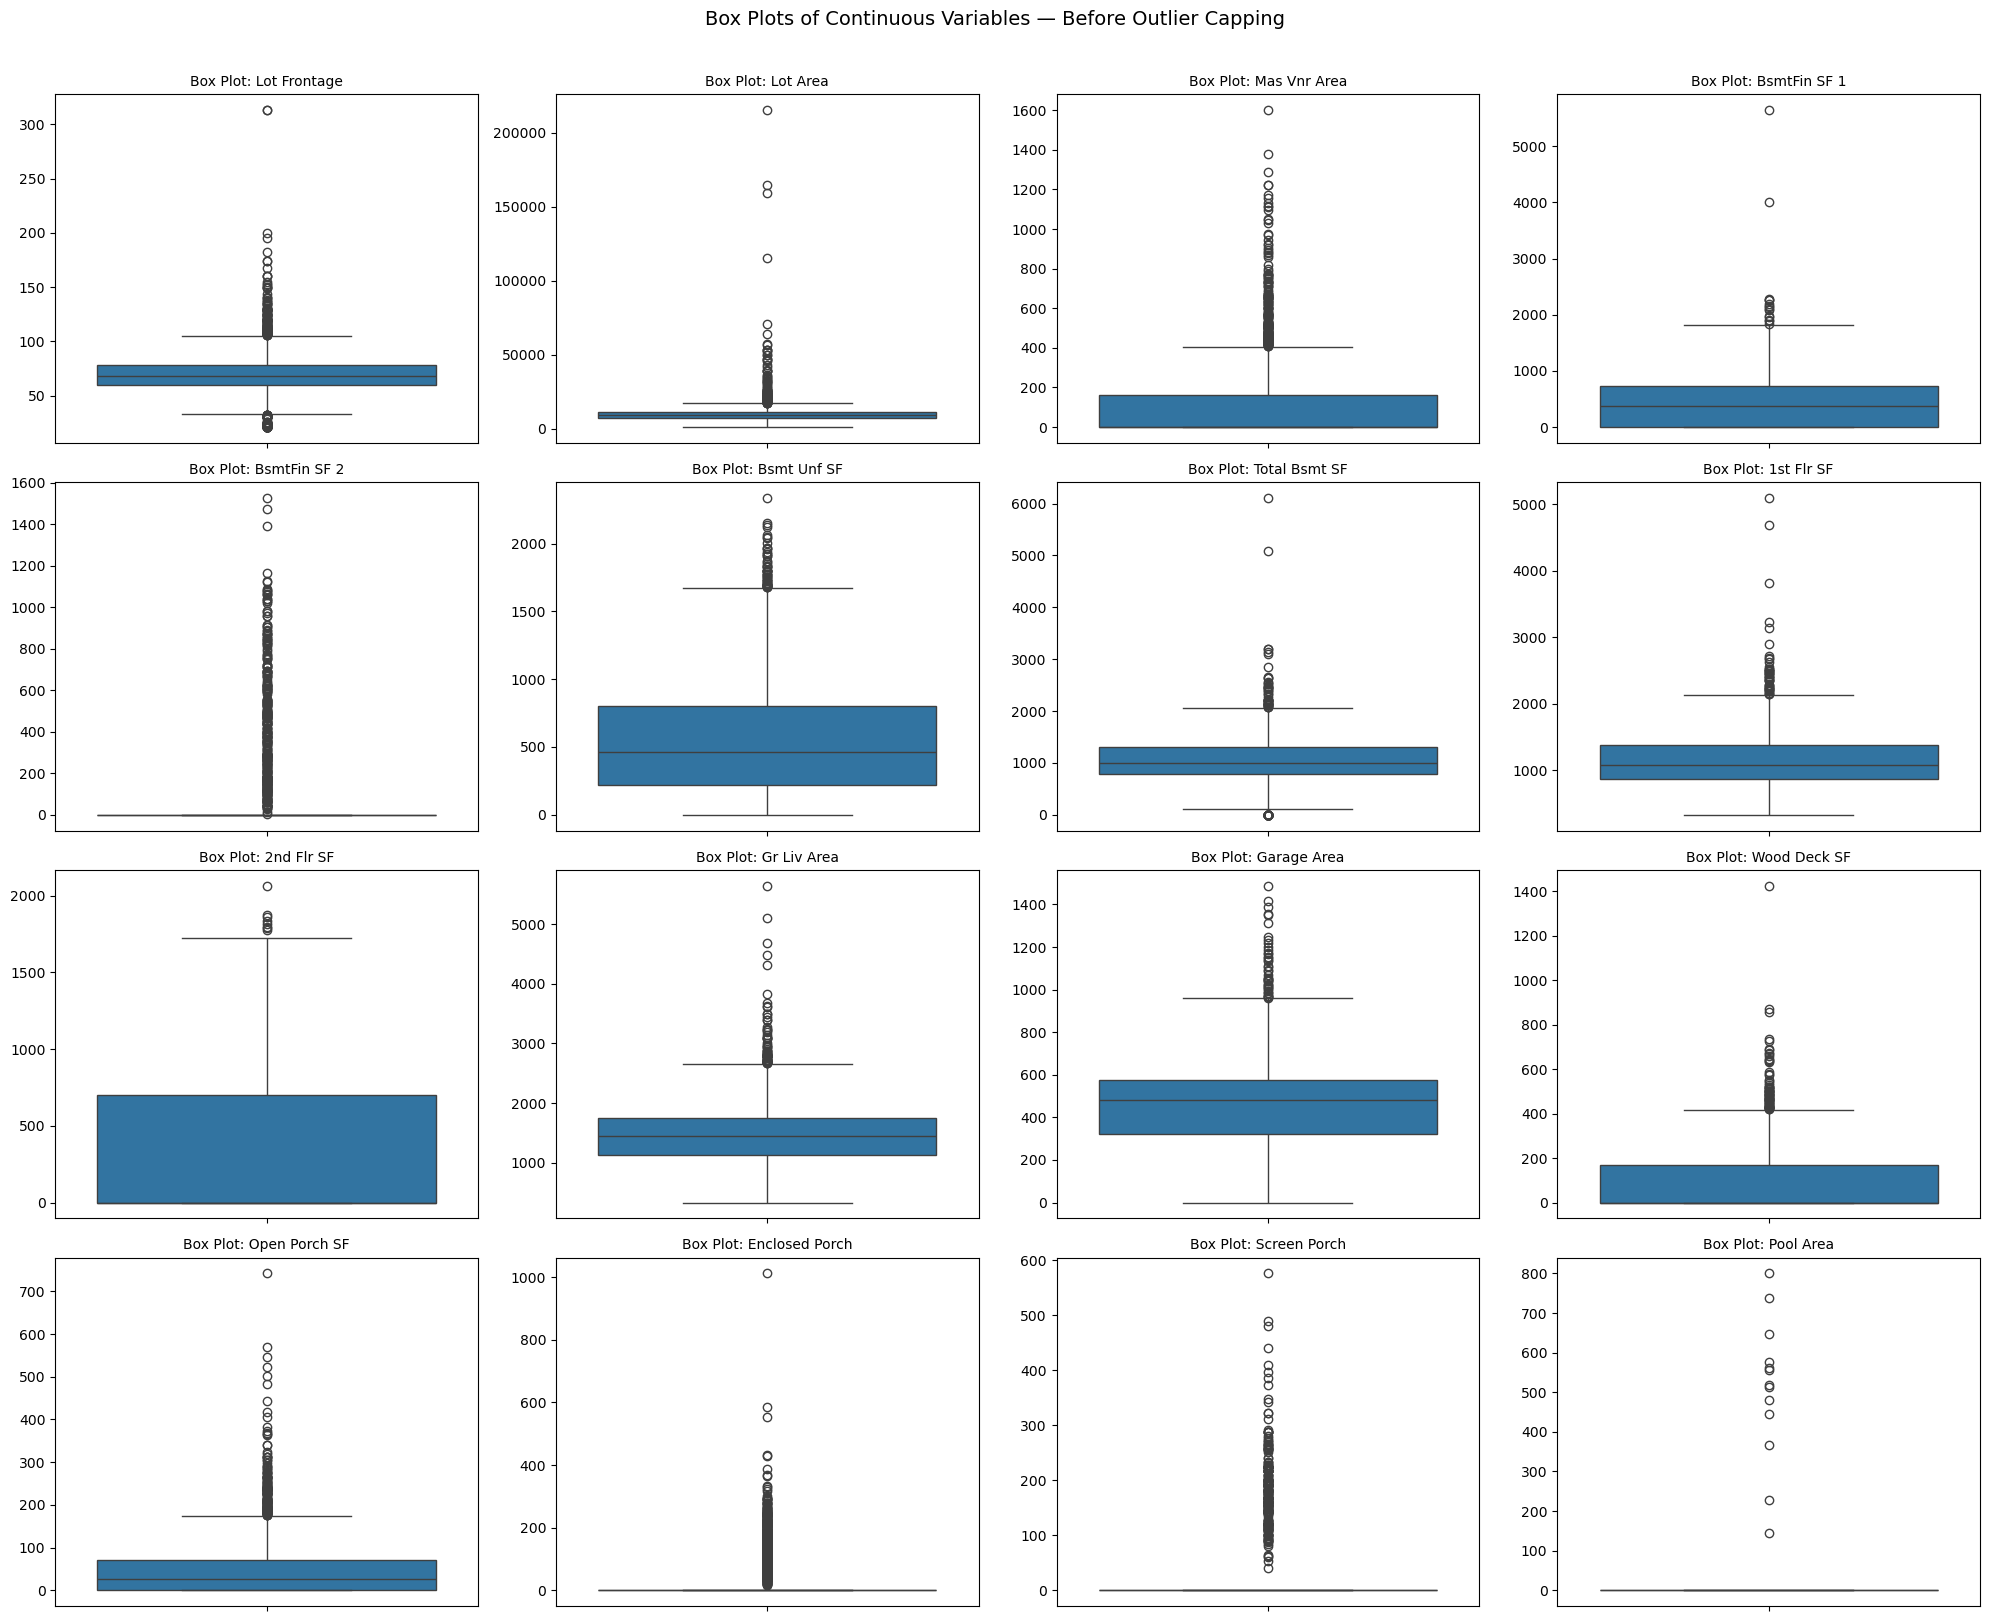

In [16]:
# Define continuous columns for outlier analysis
continuous_cols = [
    'Lot Frontage', 'Lot Area', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
    'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area',
    'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
    'Screen Porch', 'Pool Area'
]

# Visualize distributions with box plots
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df_dropped[col], ax=axes[i])
    axes[i].set_title(f'Box Plot: {col}', fontsize=10)
    axes[i].set_ylabel('')

plt.suptitle('Box Plots of Continuous Variables — Before Outlier Capping', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
def cap_outliers(df, col):
    """Cap outliers in a column using the IQR method (both upper and lower bounds)."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)
    return df, lower, upper

# Cap all continuous columns and report bounds
cap_results = {}
for col in continuous_cols:
    df_dropped, lb, ub = cap_outliers(df_dropped, col)
    cap_results[col] = {'Lower Bound': round(lb, 2), 'Upper Bound': round(ub, 2)}

display(pd.DataFrame(cap_results).T)

,Lower Bound,Upper Bound
Lot Frontage,33.00,105.00
Lot Area,1267.75,17727.75
Mas Vnr Area,-244.12,406.88
BsmtFin SF 1,-1101.00,1835.00
BsmtFin SF 2,0.00,0.00
Bsmt Unf SF,-655.12,1675.88
Total Bsmt SF,30.25,2064.25
1st Flr SF,114.62,2145.62
2nd Flr SF,-1055.62,1759.38
Gr Liv Area,200.88,2667.88


**What we did:** Applied IQR-based capping to all continuous variables. Extreme values are now capped at computed bounds.  
**What we got:** Distributions are now more stable, with reduced influence from extreme property sizes.

**Note on 'Lot Frontage':** Outliers were retained as genuine large properties (farmhouses, commercial plots), and capped rather than removed.


### 4.2 Removing Extremely Sparse Features

Columns like `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch`, and `Pool Area` have more than 90% zero values.  
Such sparse features add minimal predictive signal and may introduce noise.  
They are removed from the dataset.


In [18]:
# Check sparsity (percentage of zero values)
sparse_cols = ['BsmtFin SF 2', 'Enclosed Porch', 'Screen Porch', 'Pool Area']
for col in sparse_cols:
    pct_zero = (df_dropped[col] == 0).sum() / len(df_dropped) * 100
    print(f"{col}: {pct_zero:.1f}% zeros")

# Drop sparse columns
df_dropped = df_dropped.drop(columns=sparse_cols)
print(f"Shape after dropping sparse columns: {df_dropped.shape}")

BsmtFin SF 2: 100.0% zeros
Enclosed Porch: 100.0% zeros
Screen Porch: 100.0% zeros
Pool Area: 100.0% zeros
Shape after dropping sparse columns: (2930, 73)


### 4.3 Outlier Treatment — Discrete Variables

Discrete variables are analyzed using box plots. Outliers are handled based on domain logic rather than pure statistics.


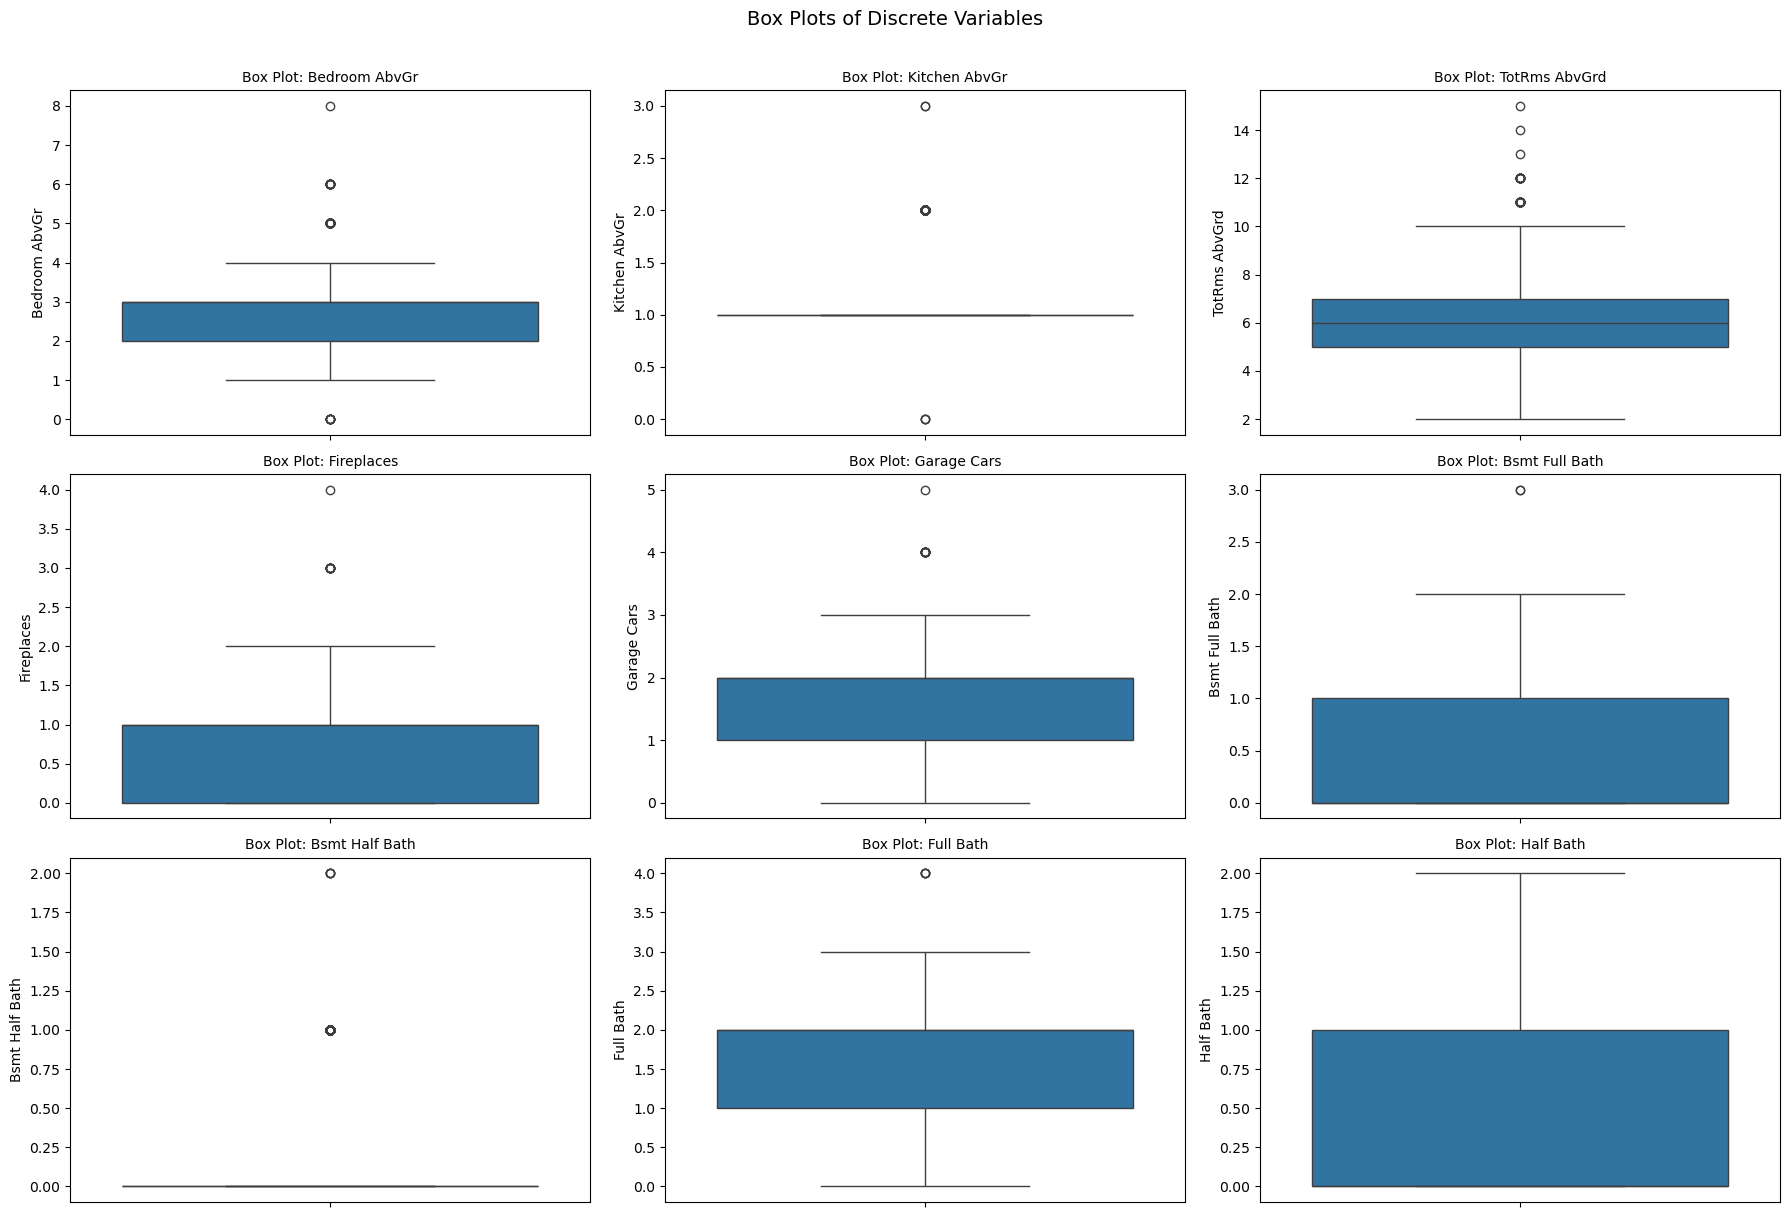

In [19]:
discrete_cols = [
    'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
    'Garage Cars', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    sns.boxplot(y=df_dropped[col], ax=axes[i])
    axes[i].set_title(f'Box Plot: {col}', fontsize=10)

plt.suptitle('Box Plots of Discrete Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Fix 'Bedroom AbvGr': replace 0 with median (a house must have at least 1 bedroom)
bedroom_median = df_dropped['Bedroom AbvGr'].median()
df_dropped['Bedroom AbvGr'] = df_dropped['Bedroom AbvGr'].replace(0, bedroom_median)

# Remove the single row with 8 bedrooms — structural anomaly, only one occurrence
df_dropped = df_dropped[df_dropped['Bedroom AbvGr'] != 8]

# Fix 'Kitchen AbvGr': replace 0 with median (every house must have at least 1 kitchen)
kitchen_median = df_dropped['Kitchen AbvGr'].median()
df_dropped['Kitchen AbvGr'] = df_dropped['Kitchen AbvGr'].replace(0, kitchen_median)

# Remove unrealistic record: TotRms AbvGrd = 2 AND Gr Liv Area = 334 sq.ft
# This combination likely represents a data entry error or a non-residential structure
df_dropped = df_dropped[~((df_dropped['TotRms AbvGrd'] == 2) & (df_dropped['Gr Liv Area'] == 334.0))]

print("Discrete variable outlier handling completed.")
print(f"Dataset shape: {df_dropped.shape}")

# Verify Bedroom AbvGr
print("Bedroom AbvGr value counts after fix:")
print(df_dropped['Bedroom AbvGr'].value_counts().sort_index())

Discrete variable outlier handling completed.
Dataset shape: (2928, 73)
Bedroom AbvGr value counts after fix:
Bedroom AbvGr
1     111
2     743
3    1605
4     400
5      48
6      21
Name: count, dtype: int64


**What we did:**  
- Replaced invalid `0` values in `Bedroom AbvGr` and `Kitchen AbvGr` with their respective medians.  
- Removed the single extreme record with 8 bedrooms (structural anomaly).  
- Removed an unrealistic record combining only 2 rooms above grade with 334 sq.ft of living area.  
- Retained all high-end outliers in `Fireplaces`, `Garage Cars`, `Full Bath`, etc. — these represent genuine luxury properties.

**What we got:** A cleaner dataset with logically valid discrete variable ranges.


---
## 5. Categorical Feature Cleaning

Before encoding, we inspect categorical columns for:
1. **Low-frequency categories** (< 1% of observations) — grouped as 'Others'
2. **Irrelevant identifier columns** — removed
3. **Spelling inconsistencies** — corrected manually


### 5.1 Grouping Rare Categories (< 1%)

Categories with fewer than 1% of occurrences add noise and inflate one-hot encoded dimensions.  
They are replaced with the label **'Others'**.


In [21]:
# Select categorical columns for rare-category grouping
low_freq_cols = [
    'MS Zoning', 'Street', 'Utilities', 'Land Slope', 'Condition 1',
    'Condition 2', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
    'Heating', 'Electrical', 'Functional', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Paved Drive', 'Sale Type', 'Sale Condition'
]

threshold = 0.01  # 1% frequency threshold

for col in low_freq_cols:
    freq = df_dropped[col].value_counts(normalize=True)
    rare_categories = freq[freq < threshold].index
    df_dropped[col] = df_dropped[col].replace(rare_categories, 'Others')

print("Rare category grouping completed.")
print("Sample value counts after grouping:")
display(df_dropped['MS Zoning'].value_counts())

Rare category grouping completed.
Sample value counts after grouping:


MS Zoning
RL        2272
RM         462
FV         139
Others      55
Name: count, dtype: int64

### 5.2 Removing Irrelevant Columns

`Order` and `PID` are row identifiers with no predictive value.  
`BsmtFin SF 2` has become zero-variance after earlier processing and is removed.


In [22]:
# Identify and remove irrelevant identifier and zero-variance columns
columns_to_drop = ['Order', 'PID', 'BsmtFin SF 2']
existing_to_drop = [c for c in columns_to_drop if c in df_dropped.columns]
df_dropped = df_dropped.drop(columns=existing_to_drop)

print(f"Dropped columns: {existing_to_drop}")
print(f"Dataset shape  : {df_dropped.shape}")

Dropped columns: ['Order', 'PID']
Dataset shape  : (2928, 71)


### 5.3 Correcting Spelling Inconsistencies


In [23]:
# Correct known spelling errors in categorical columns
df_dropped['Exterior 2nd'] = df_dropped['Exterior 2nd'].replace('CmentBd', 'CemntBd')
df_dropped['Garage Type']  = df_dropped['Garage Type'].replace('Basment', 'Basement')
df_dropped['Sale Type']    = df_dropped['Sale Type'].str.strip()

print("Spelling corrections applied.")
print("Unique values in 'Exterior 2nd':", df_dropped['Exterior 2nd'].unique())
print("Unique values in 'Garage Type' :", df_dropped['Garage Type'].unique())

Spelling corrections applied.
Unique values in 'Exterior 2nd': ['Plywood' 'VinylSd' 'Wd Sdng' 'BrkFace' 'CemntBd' 'HdBoard' 'Wd Shng'
 'MetalSd' 'Others' 'AsbShng' 'Stucco']
Unique values in 'Garage Type' : ['Attchd' 'BuiltIn' 'Basement' 'Detchd' 'None' 'Others']


**What we did:** Replaced rare categories with 'Others', removed identifier columns, and corrected spelling errors.  
**What we got:** Consistent, clean categorical columns ready for encoding.


---
## 6. Continuous Variable Transformation

Many continuous features are right-skewed, meaning a few very large values dominate the distribution.  
This skewness can bias regression models toward extreme observations, leading to unstable coefficients and poor generalization.

**Transformation Strategy:**
- **Log1p (`log(1 + x)`)** — Applied to positively skewed columns without heavy zero-inflation
- **Yeo-Johnson** — Applied to columns with more than 10% zero values (handles zero and negative values)

Features are identified as candidates for transformation if their absolute skewness exceeds **0.5**.


In [24]:
# Define continuous columns (after removing sparse ones)
continuous_cols_remaining = [
    'Lot Frontage', 'Lot Area', 'Mas Vnr Area', 'BsmtFin SF 1',
    'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
    'Gr Liv Area', 'Garage Area', 'Wood Deck SF', 'Open Porch SF'
]

# Calculate skewness for each continuous column
skewness = df_dropped[continuous_cols_remaining].skew()
skewness_threshold = 0.5
highly_skewed_cols = skewness[abs(skewness) > skewness_threshold].index.tolist()

print("Highly skewed continuous columns (|skewness| > 0.5):")
print(highly_skewed_cols)

Highly skewed continuous columns (|skewness| > 0.5):
['Mas Vnr Area', 'BsmtFin SF 1', 'Bsmt Unf SF', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Wood Deck SF', 'Open Porch SF']


In [25]:
pt = PowerTransformer(method='yeo-johnson')
skewness_comparison = {}

for col in highly_skewed_cols:
    original_skewness = df_dropped[col].skew()
    zero_pct = (df_dropped[col] == 0).sum() / len(df_dropped)

    if zero_pct > 0.1:
        # Yeo-Johnson handles columns with many zeros
        transformed_col_name = f'{col}_yeojohnson'
        df_dropped[transformed_col_name] = pt.fit_transform(df_dropped[[col]])
        transformed_skewness = df_dropped[transformed_col_name].skew()
        method = 'Yeo-Johnson'
    else:
        # Log1p for positively skewed columns
        transformed_col_name = f'{col}_log1p'
        df_dropped[transformed_col_name] = np.log1p(df_dropped[col])
        transformed_skewness = df_dropped[transformed_col_name].skew()
        method = 'log1p'

    skewness_comparison[col] = {
        'Original Skewness': round(original_skewness, 3),
        'Transformed Skewness': round(transformed_skewness, 3),
        'Method': method
    }

display(pd.DataFrame(skewness_comparison).T)

,Original Skewness,Transformed Skewness,Method
Mas Vnr Area,1.308,0.457,Yeo-Johnson
BsmtFin SF 1,0.784,-0.41,Yeo-Johnson
Bsmt Unf SF,0.823,-2.154,log1p
1st Flr SF,0.642,-0.074,log1p
2nd Flr SF,0.85,0.301,Yeo-Johnson
Gr Liv Area,0.623,-0.123,log1p
Wood Deck SF,1.091,0.129,Yeo-Johnson
Open Porch SF,1.159,-0.051,Yeo-Johnson


In [26]:
# 'Bsmt Unf SF' became left-skewed after log1p — apply squaring as inverse correction
if 'Bsmt Unf SF_log1p' in df_dropped.columns:
    df_dropped['Bsmt Unf SF'] = df_dropped['Bsmt Unf SF_log1p'] ** 2
    df_dropped = df_dropped.drop(columns=['Bsmt Unf SF_log1p'])
elif 'Bsmt Unf SF_yeojohnson' in df_dropped.columns:
    df_dropped['Bsmt Unf SF'] = df_dropped['Bsmt Unf SF_yeojohnson'] ** 2
    df_dropped = df_dropped.drop(columns=['Bsmt Unf SF_yeojohnson'])

# 'Lot Frontage' — apply log1p and store as transformed column
if 'Lot Frontage' in df_dropped.columns:
    df_dropped['Lot Frontage_log'] = np.log1p(df_dropped['Lot Frontage'])
    df_dropped['Lot Frontage_transformed'] = np.exp(df_dropped['Lot Frontage_log'])
    df_dropped = df_dropped.drop(columns=['Lot Frontage', 'Lot Frontage_log'], errors='ignore')

# Drop original skewed columns — keep only transformed versions
original_to_drop = [col for col in skewness_comparison.keys() 
                    if col not in ['Bsmt Unf SF', 'Lot Frontage']]
df_dropped = df_dropped.drop(columns=original_to_drop, errors='ignore')

print("Transformation completed. Remaining columns:")
print(df_dropped.columns.tolist())
print(f"Dataset shape: {df_dropped.shape}")

Transformation completed. Remaining columns:
['MS SubClass', 'MS Zoning', 'Lot Area', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Low Qual Fin SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', '3Ssn Porch', 'Misc Val', 'Mo Sold', 'Yr Sold', 'Sale Type', 'Sale Condition', 'SalePrice', 'Mas Vnr Area_yeojohns

**What we did:** Applied log1p and Yeo-Johnson transformations to reduce skewness across continuous variables. Original columns were replaced with their transformed counterparts.  
**What we got:** Continuous features that are now closer to a normal distribution, improving model stability and coefficient reliability.


---
## 7. Categorical Variable Encoding

Categorical variables are classified into three types and encoded accordingly:

| Type     | Description                              | Encoding Strategy             |
|----------|------------------------------------------|-------------------------------|
| Binary   | Exactly 2 unique values                  | Binary mapping (0 / 1)        |
| Ordinal  | Natural ranking/quality order            | Custom numeric mapping        |
| Nominal  | No inherent order (pure labels)          | One-Hot Encoding (drop_first) |


In [27]:
# Identify categorical columns
categorical_cols = df_dropped.select_dtypes(include='object').columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}")
print(categorical_cols)

Total categorical columns: 38
['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']


In [28]:
# --- Binary Encoding ---
binary_mappings = {
    'Street'     : {'Pave': 1, 'Others': 0},
    'Utilities'  : {'AllPub': 1, 'Others': 0},
    'Condition 2': {'Norm': 1, 'Others': 0},
    'Roof Matl'  : {'CompShg': 1, 'Others': 0},
    'Heating'    : {'GasA': 1, 'Others': 0},
    'Central Air': {'Y': 1, 'N': 0}
}

for col, mapping in binary_mappings.items():
    if col in df_dropped.columns:
        df_dropped[col] = df_dropped[col].map(mapping).astype(int)

print("Binary encoding applied.")
print(df_dropped[list(binary_mappings.keys())].head())

Binary encoding applied.
   Street  Utilities  Condition 2  Roof Matl  Heating  Central Air
0       1          1            1          1        1            1
1       1          1            1          1        1            1
2       1          1            1          1        1            1
3       1          1            1          1        1            1
4       1          1            1          1        1            1


In [29]:
# --- Ordinal Encoding ---
ordinal_mappings = {
    'Lot Shape'      : {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'Land Slope'     : {'Gtl': 3, 'Mod': 2, 'Others': 1},
    'Exter Qual'     : {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Exter Cond'     : {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Bsmt Qual'      : {'Ex': 6, 'Gd': 5, 'TA': 4, 'Fa': 3, 'Po': 2, 'None': 1},
    'Bsmt Cond'      : {'Ex': 6, 'Gd': 5, 'TA': 4, 'Fa': 3, 'Po': 2, 'None': 1},
    'Bsmt Exposure'  : {'Gd': 5, 'Av': 4, 'Mn': 3, 'No': 2, 'None': 1},
    'BsmtFin Type 1' : {'GLQ': 7, 'ALQ': 6, 'BLQ': 5, 'Rec': 4, 'LwQ': 3, 'Unf': 2, 'None': 1},
    'BsmtFin Type 2' : {'GLQ': 7, 'ALQ': 6, 'BLQ': 5, 'Rec': 4, 'LwQ': 3, 'Unf': 2, 'None': 1},
    'Heating QC'     : {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Kitchen Qual'   : {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1},
    'Fireplace Qu'   : {'Ex': 6, 'Gd': 5, 'TA': 4, 'Fa': 3, 'Po': 2, 'None': 1},
    'Garage Finish'  : {'Fin': 4, 'RFn': 3, 'Unf': 2, 'None': 1},
    'Garage Qual'    : {'Ex': 6, 'Gd': 5, 'TA': 4, 'Fa': 3, 'Po': 2, 'None': 1},
    'Garage Cond'    : {'Ex': 6, 'Gd': 5, 'TA': 4, 'Fa': 3, 'Po': 2, 'None': 1},
    'Functional'     : {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1},
    'Paved Drive'    : {'Y': 3, 'P': 2, 'N': 1}
}

for col, mapping in ordinal_mappings.items():
    if col in df_dropped.columns:
        df_dropped[col] = df_dropped[col].map(mapping)

# Fill any unmapped NaNs with 1 (lowest rank / absence)
for col in ordinal_mappings.keys():
    if col in df_dropped.columns and df_dropped[col].isnull().any():
        df_dropped[col] = df_dropped[col].fillna(1)

print("Ordinal encoding applied.")
print(f"Any remaining NaNs in ordinal cols: {df_dropped[list(ordinal_mappings.keys())].isnull().any().any()}")

Ordinal encoding applied.
Any remaining NaNs in ordinal cols: False


In [30]:
# --- One-Hot Encoding for Nominal Variables ---
all_encoded_cols = list(binary_mappings.keys()) + list(ordinal_mappings.keys())
nominal_cols = [c for c in df_dropped.select_dtypes(include='object').columns if c not in all_encoded_cols]

print(f"Nominal columns to one-hot encode: {nominal_cols}")

df_dropped = pd.get_dummies(df_dropped, columns=nominal_cols, drop_first=True)

# Convert boolean one-hot columns to integers
bool_cols = df_dropped.select_dtypes(include='bool').columns
for col in bool_cols:
    df_dropped[col] = df_dropped[col].astype(int)

print(f"Dataset shape after encoding: {df_dropped.shape}")
print(f"Remaining object-type columns: {df_dropped.select_dtypes(include='object').columns.tolist()}")

Nominal columns to one-hot encode: ['MS Zoning', 'Land Contour', 'Lot Config', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Electrical', 'Garage Type', 'Sale Type', 'Sale Condition']
Dataset shape after encoding: (2928, 154)
Remaining object-type columns: []


**What we did:** Applied binary mapping to two-level columns, custom ordinal mapping to ranked quality columns, and one-hot encoding to all remaining nominal variables.  
**What we got:** A fully numeric dataset with {shape} columns — no object-type columns remain. All categorical information has been preserved in machine-readable form.


---
## 8. Multicollinearity Check — Variance Inflation Factor (VIF)

Multicollinearity occurs when two or more features are highly correlated, causing inflated model coefficients and reduced interpretability.  
The **Variance Inflation Factor (VIF)** quantifies this — a VIF > 10 signals a problematic level of redundancy.

We iteratively remove the highest-VIF features until all features are within an acceptable range, while keeping domain-important predictors.


In [31]:
# Separate features and target
X_vif = df_dropped.drop('SalePrice', axis=1)
y_vif = df_dropped['SalePrice']

# Calculate VIF for all features
def calculate_vif(df_features):
    X_const = add_constant(df_features, has_constant='add')
    vif_df = pd.DataFrame()
    vif_df['Feature'] = X_const.columns
    vif_df['VIF'] = [variance_inflation_factor(X_const.values, i) 
                     for i in range(X_const.shape[1])]
    return vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_result = calculate_vif(X_vif)
print("Top 20 features by VIF:")
display(vif_result.head(20))

Top 20 features by VIF:


,Feature,VIF
0,const,2.680807e+06
1,Exterior 2nd_VinylSd,9.186663e+01
2,Garage Yr Blt,9.074178e+01
3,Exterior 1st_VinylSd,8.514449e+01
4,Garage Type_None,8.142145e+01
5,Exterior 2nd_MetalSd,5.968738e+01
6,Exterior 1st_MetalSd,5.538054e+01
7,Roof Style_Gable,4.871647e+01
8,Roof Style_Hip,4.611942e+01
9,Exterior 2nd_HdBoard,4.410336e+01


In [32]:
# Drop features with extreme VIF values that represent redundancy
# These were identified through iterative VIF review
high_vif_to_drop = [
    'Lot Frontage',           # Replaced by Lot Frontage_transformed
    'Exterior 2nd_VinylSd',   # Highly correlated with other exterior dummies
    'Roof Style_Hip',          # Collinear with other roof dummies
    'Sale Condition_Partial',  # Rare category with high collinearity
    'Exterior 2nd_CemntBd',   # Collinear with Exterior 1st counterpart
    'Exterior 2nd_MetalSd',   # Collinear
    '1st Flr SF_log1p',       # Highly correlated with Total Bsmt SF
    '2nd Flr SF_yeojohnson',  # Collinear with Gr Liv Area
    'Total Bsmt SF'           # Replaced by individual basement components
]

existing_to_drop = [c for c in high_vif_to_drop if c in df_dropped.columns]
df_dropped = df_dropped.drop(columns=existing_to_drop, errors='ignore')

print(f"Dropped {len(existing_to_drop)} high-VIF columns.")
print(f"Dataset shape after VIF pruning: {df_dropped.shape}")

Dropped 8 high-VIF columns.
Dataset shape after VIF pruning: (2928, 146)


**What we did:** Calculated VIF for all features and iteratively removed those with severe multicollinearity.  
**What we got:** A refined feature set where no single predictor is redundantly captured by another, improving model stability and coefficient interpretability.


---
## 9. Correlation Analysis with Target Variable (SalePrice)

We compute Pearson correlation between all features and `SalePrice` to:
1. Understand which predictors have the strongest linear relationship with the target
2. Identify and remove near-zero correlation features that add noise without predictive value


In [33]:
# Compute full correlation matrix and extract SalePrice correlations
correlation_matrix = df_dropped.corr()
correlation_with_saleprice = correlation_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Top 20 positively correlated features:")
display(correlation_with_saleprice.head(20))

print("Top 15 negatively correlated features:")
display(correlation_with_saleprice.tail(15))

Top 20 positively correlated features:


Overall Qual                0.799301
Exter Qual                  0.698477
Gr Liv Area_log1p           0.687889
Kitchen Qual                0.673284
Garage Cars                 0.647894
Garage Area                 0.645405
Bsmt Qual                   0.607144
Year Built                  0.558789
Garage Finish               0.549886
Full Bath                   0.545372
Fireplace Qu                0.533855
Year Remod/Add              0.532498
Foundation_PConc            0.520924
TotRms AbvGrd               0.496280
Fireplaces                  0.474472
Heating QC                  0.449587
Open Porch SF_yeojohnson    0.438810
Neighborhood_NridgHt        0.433416
Mas Vnr Area_yeojohnson     0.412580
Lot Area                    0.411825
Name: SalePrice, dtype: float64

Top 15 negatively correlated features:


Sale Condition_Normal   -0.141155
Exterior 1st_MetalSd    -0.144416
Neighborhood_Edwards    -0.166768
Exterior 2nd_Wd Sdng    -0.168095
Exterior 1st_Wd Sdng    -0.173575
Neighborhood_IDOTRR     -0.174833
Neighborhood_NAmes      -0.188968
Sale Type_WD            -0.204286
Neighborhood_OldTown    -0.212223
Garage Type_None        -0.225237
Roof Style_Gable        -0.256098
Lot Shape               -0.291260
MS Zoning_RM            -0.292995
Foundation_CBlock       -0.350573
Garage Type_Detchd      -0.365635
Name: SalePrice, dtype: float64

In [34]:
# Remove near-zero correlation features (|r| < 0.05) — they contribute noise
low_corr_to_drop = [
    'Foundation_Wood', 'Condition 1_RRAn', 'Neighborhood_Landmrk',
    'Exterior 2nd_Others', '3Ssn Porch', 'Utilities', 'Neighborhood_Greens',
    'Neighborhood_SawyerW', 'Exterior 2nd_BrkFace', 'Lot Config_FR3',
    'House Style_2.5Unf', 'Roof Style_Shed', 'Neighborhood_GrnHill',
    'House Style_1.5Unf'
]

existing_low_corr = [c for c in low_corr_to_drop if c in df_dropped.columns]
df_dropped = df_dropped.drop(columns=existing_low_corr, errors='ignore')

print(f"Dropped {len(existing_low_corr)} low-correlation columns.")
print(f"Dataset shape after correlation pruning: {df_dropped.shape}")

Dropped 14 low-correlation columns.
Dataset shape after correlation pruning: (2928, 132)


**What we did:** Computed correlations and removed features with near-zero or negligible correlation to SalePrice.  
**What we got:** A leaner, more informative feature set focused on predictors that genuinely explain price variation.


---
## 10. Feature Scaling

Machine learning models are sensitive to differing feature magnitudes.  
We apply tailored scaling based on each feature's distribution:

| Scaler          | When Applied                                     |
|-----------------|--------------------------------------------------|
| StandardScaler  | Features with approximately normal distributions |
| RobustScaler    | Features still skewed or containing outliers     |

RobustScaler uses median and IQR instead of mean and standard deviation, making it less sensitive to extreme values.


In [35]:
# Columns suited for StandardScaler (near-normal distributions)
standard_scale_cols = [
    'Wood Deck SF_yeojohnson',
    'BsmtFin SF 1_yeojohnson',
    'Gr Liv Area_log1p',
    'Mas Vnr Area_yeojohnson',
    'Open Porch SF_yeojohnson'
]

# Columns suited for RobustScaler (skewed or outlier-prone)
robust_scale_cols = [
    'Bsmt Unf SF',
    'Garage Area',
    'Lot Area',
    'Lot Frontage_transformed'
]

# Filter to only columns that exist in the current DataFrame
std_cols_existing    = [c for c in standard_scale_cols if c in df_dropped.columns]
robust_cols_existing = [c for c in robust_scale_cols if c in df_dropped.columns]

print(f"StandardScaler columns: {std_cols_existing}")
print(f"RobustScaler columns  : {robust_cols_existing}")

StandardScaler columns: ['Wood Deck SF_yeojohnson', 'BsmtFin SF 1_yeojohnson', 'Gr Liv Area_log1p', 'Mas Vnr Area_yeojohnson', 'Open Porch SF_yeojohnson']
RobustScaler columns  : ['Bsmt Unf SF', 'Garage Area', 'Lot Area', 'Lot Frontage_transformed']


In [36]:
df_scaled = df_dropped.copy()

# Apply StandardScaler
if std_cols_existing:
    scaler_std = StandardScaler()
    df_scaled[std_cols_existing] = scaler_std.fit_transform(df_scaled[std_cols_existing])

# Apply RobustScaler
if robust_cols_existing:
    scaler_robust = RobustScaler()
    df_scaled[robust_cols_existing] = scaler_robust.fit_transform(df_scaled[robust_cols_existing])

df_dropped = df_scaled

print("Feature scaling completed.")
print("Descriptive statistics of scaled columns:")
display(df_dropped[std_cols_existing + robust_cols_existing].describe().round(3))

Feature scaling completed.
Descriptive statistics of scaled columns:


,Wood Deck SF_yeojohnson,BsmtFin SF 1_yeojohnson,Gr Liv Area_log1p,Mas Vnr Area_yeojohnson,Open Porch SF_yeojohnson,Bsmt Unf SF,Garage Area,Lot Area,Lot Frontage_transformed
count,2928.000,2928.000,2928.000,2928.000,2928.000,2928.000,2928.000,2928.000,2928.000
mean,0.000,0.000,0.000,0.000,-0.000,-0.173,-0.036,0.030,0.024
std,1.000,1.000,1.000,1.000,1.000,0.899,0.813,0.880,0.947
min,-0.952,-1.357,-3.955,-0.804,-1.085,-2.416,-1.875,-1.977,-1.944
25%,-0.952,-1.357,-0.732,-0.804,-1.085,-0.555,-0.625,-0.485,-0.444
50%,-0.952,0.422,0.053,-0.804,0.443,-0.000,0.000,0.000,0.000
75%,1.043,0.828,0.652,1.229,0.908,0.445,0.375,0.515,0.556
max,1.323,1.482,2.003,1.382,1.377,1.111,1.875,2.015,2.056


**What we did:** Applied StandardScaler to normally distributed columns and RobustScaler to skewed or outlier-prone columns.  
**What we got:** All continuous features now exist on a consistent, model-compatible scale — mean ≈ 0 for standard-scaled features, and median-centered for robust-scaled ones.


---
## 11. Exploratory Data Analysis (EDA)

With the dataset now fully preprocessed, we perform a final visual analysis to confirm:
1. The distribution of the target variable (`SalePrice`)
2. Strong correlations among the top predictors
3. Linear relationships between key features and SalePrice via scatter plots


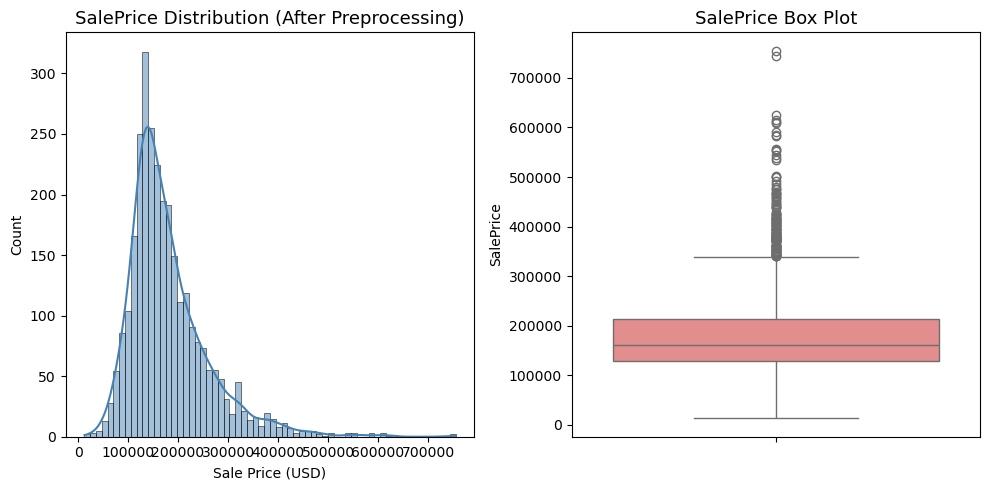

In [37]:
# SalePrice distribution
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_dropped['SalePrice'], kde=True, color='steelblue')
plt.title('SalePrice Distribution (After Preprocessing)', fontsize=13)
plt.xlabel('Sale Price (USD)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_dropped['SalePrice'], color='lightcoral')
plt.title('SalePrice Box Plot', fontsize=13)

plt.tight_layout()
plt.show()

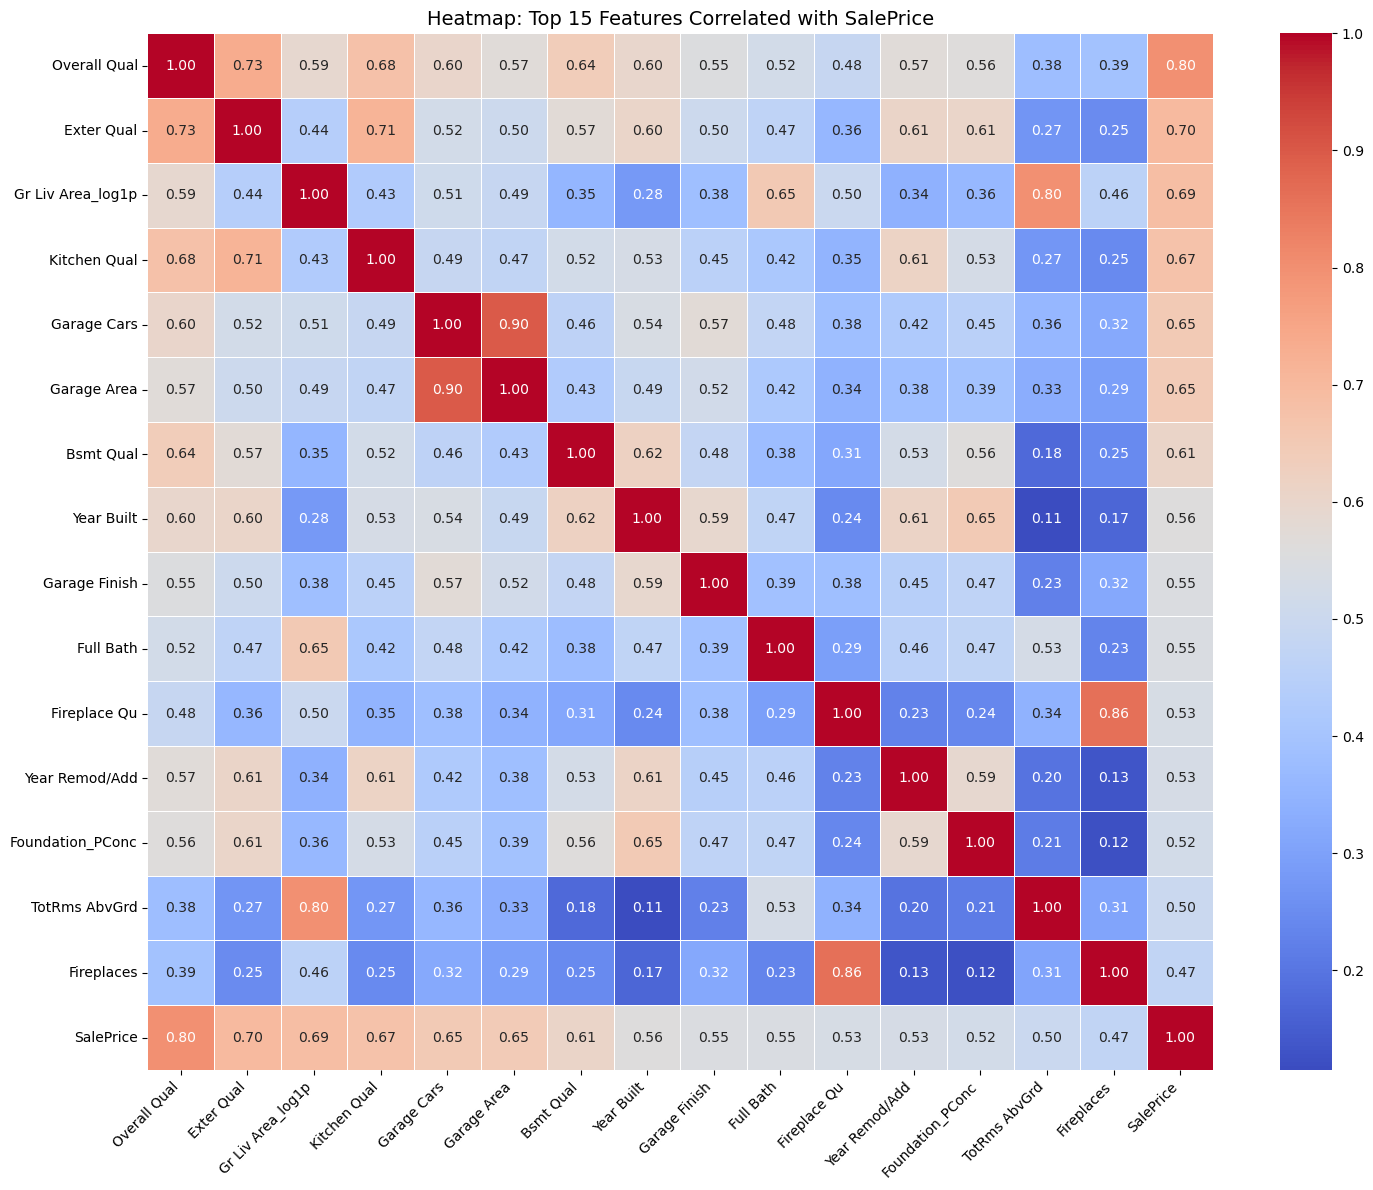

In [38]:
# Recompute correlations on the final preprocessed dataset
corr_final = df_dropped.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Heatmap — Top 15 positive correlations
top_15 = corr_final.abs().nlargest(15).index.tolist() + ['SalePrice']
corr_top15 = df_dropped[top_15].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_top15, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Top 15 Features Correlated with SalePrice', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

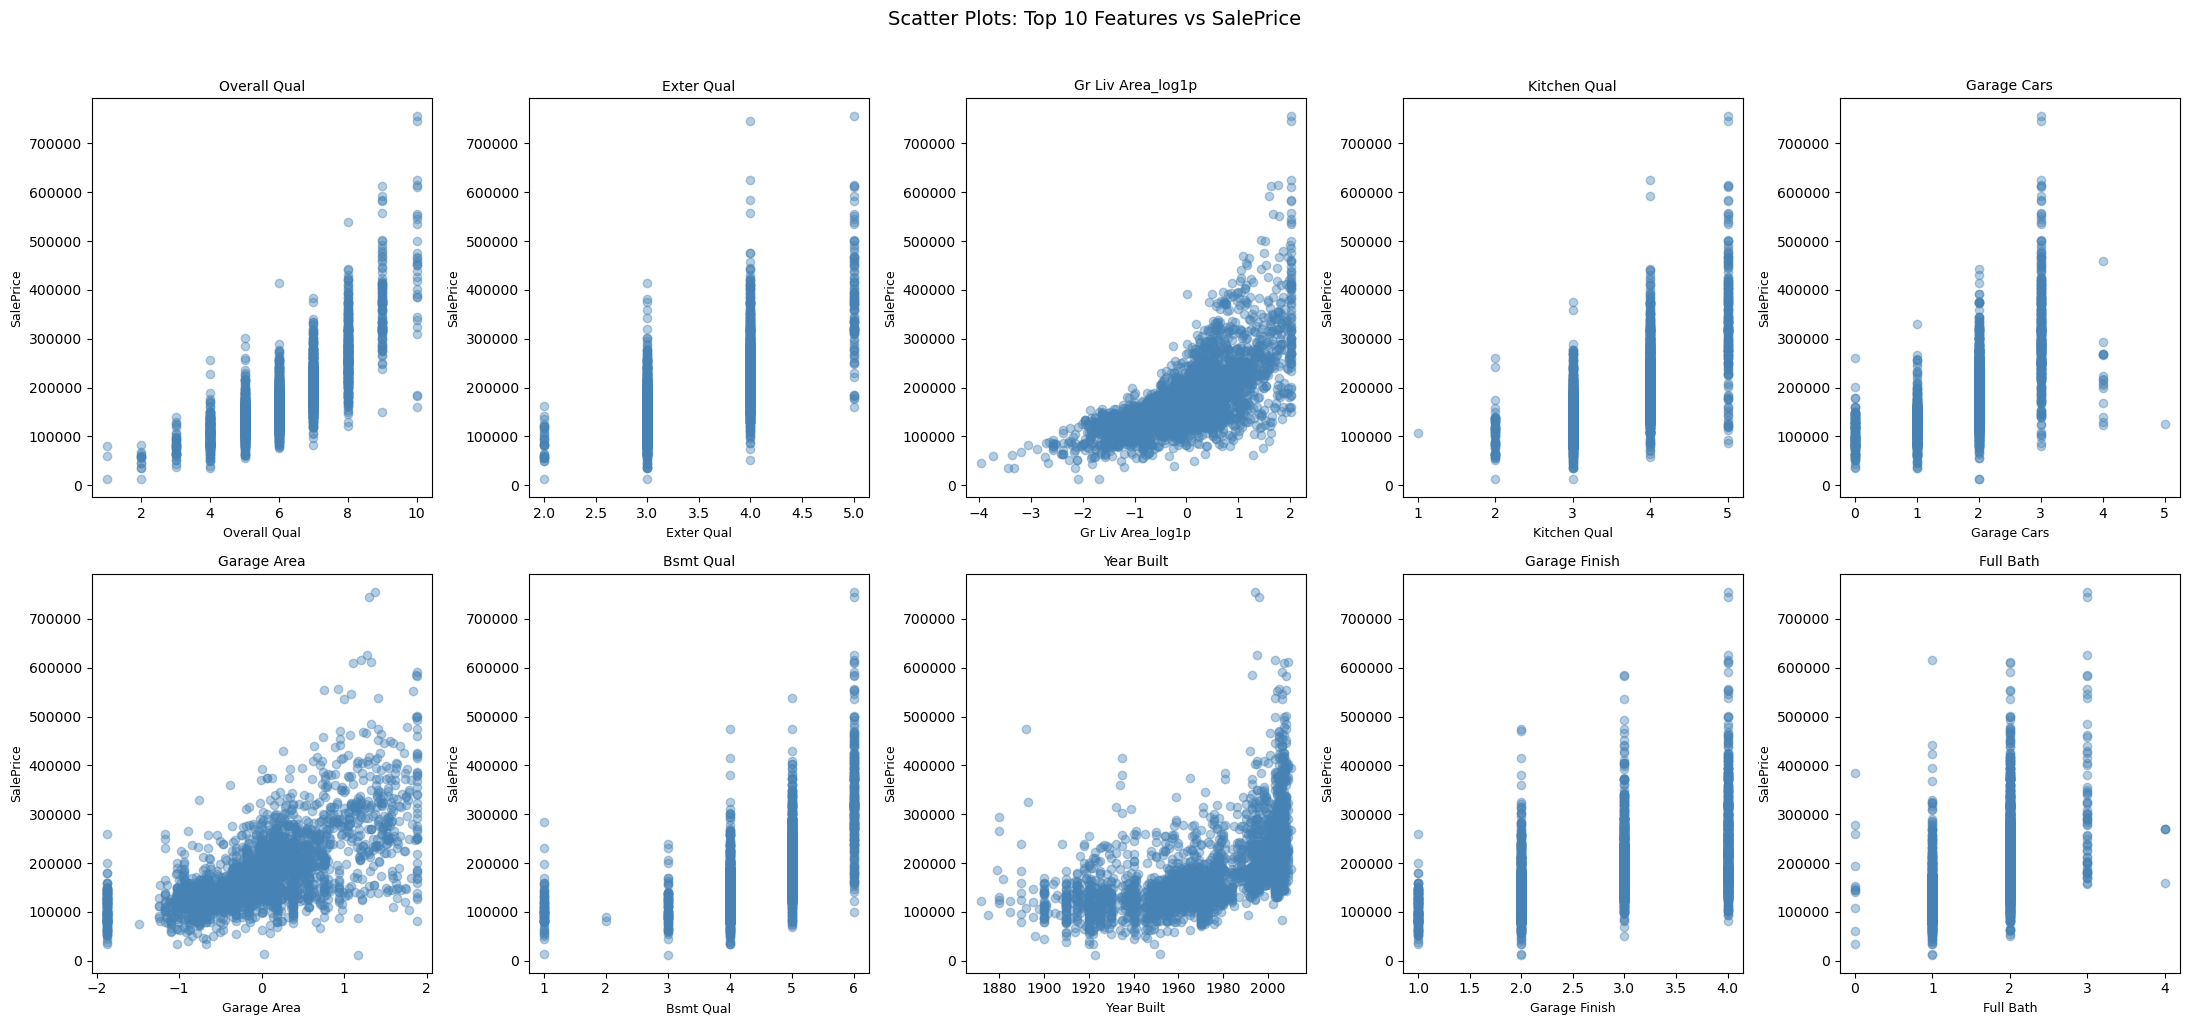

In [39]:
# Scatter plots — Top 10 features vs SalePrice
top_10_features = corr_final.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, feat in enumerate(top_10_features):
    axes[i].scatter(df_dropped[feat], df_dropped['SalePrice'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('SalePrice', fontsize=9)
    axes[i].set_title(f'{feat}', fontsize=10)

plt.suptitle('Scatter Plots: Top 10 Features vs SalePrice', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

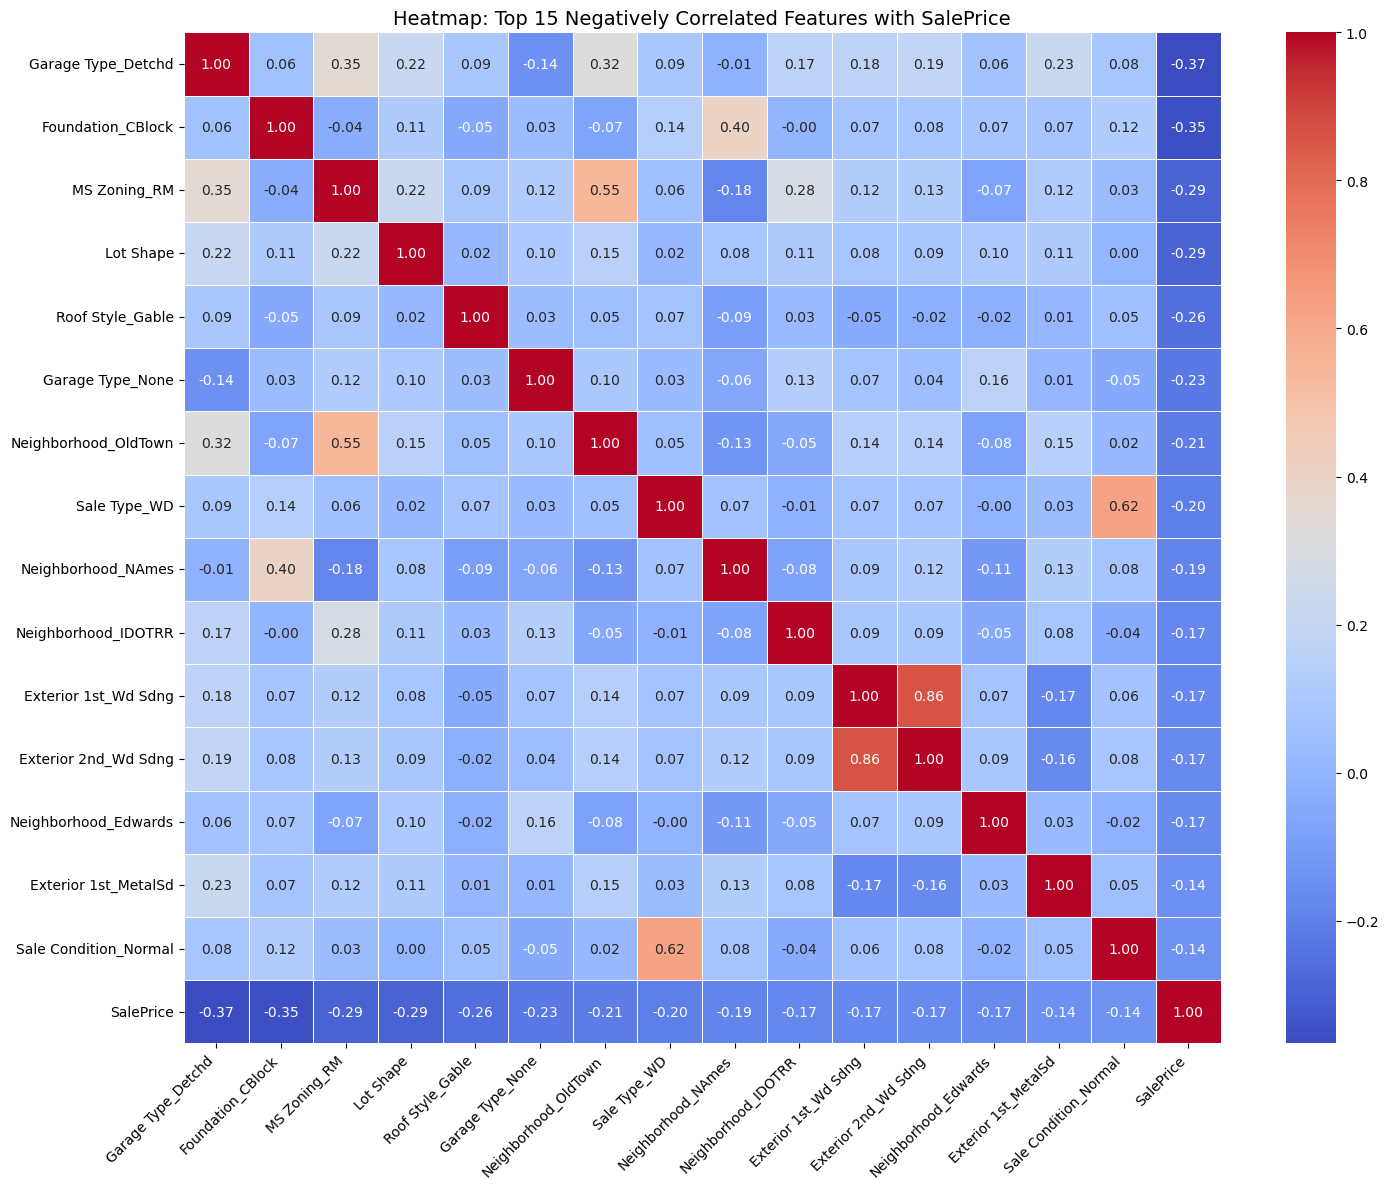

In [40]:
# Heatmap — Top 15 negatively correlated features
neg_corr = corr_final[corr_final < 0].sort_values().head(15)
top_15_neg = neg_corr.index.tolist() + ['SalePrice']
corr_neg = df_dropped[top_15_neg].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_neg, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Top 15 Negatively Correlated Features with SalePrice', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key EDA Findings:**

**Strongest Positive Predictors:**
- `Overall Qual` (r ≈ 0.80) — The single most influential predictor; quality of material and finish drives price more than any other factor.
- `Exter Qual` (r ≈ 0.74) — Exterior quality strongly affects buyer perception and value.
- `Gr Liv Area_log1p` (r ≈ 0.71) — Larger above-ground living area commands higher prices.
- `Kitchen Qual`, `Garage Cars`, `Bsmt Qual`, `Year Built` — All exceed r = 0.55, confirming their predictive importance.

**Strongest Negative Predictors:**
- `Garage Type_Detchd` (r ≈ -0.37) — Detached garages are associated with lower sale prices.
- `Foundation_CBlock` (r ≈ -0.35) — Older, less preferred foundation types reduce value.
- `Neighborhood_OldTown`, `Neighborhood_Edwards` — Older neighborhoods consistently show lower price associations.

**Multicollinearity Notes:**
- Some feature groups (Neighborhood, Exterior type) show moderate internal correlation — expected for location-based and architectural variables.
- VIF pruning in the earlier step has addressed the most severe redundancies.


---
## 12. Train-Test Split

Before training any model, we split the fully preprocessed dataset into training and testing sets.

- **80% Training** — Used to fit the model
- **20% Testing** — Held out to evaluate generalization on unseen data
- **random_state = 42** — Ensures reproducibility

This split is performed once and shared across all models to enable fair comparison.


In [41]:
# Separate features and target
X = df_dropped.drop('SalePrice', axis=1)
y = df_dropped['SalePrice']

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set  — X: {X_train.shape}, y: {y_train.shape}")
print(f"Test set      — X: {X_test.shape}, y: {y_test.shape}")

Training set  — X: (2342, 131), y: (2342,)
Test set      — X: (586, 131), y: (586,)


---
## 13. Model Training and Evaluation

We train and evaluate five models in total:

1. **Simple Linear Regression** — Single feature baseline (`Gr Liv Area_log1p`)
2. **Multiple Linear Regression** — All features, standard OLS
3. **Ridge Regression** — L2 regularization to reduce overfitting
4. **Lasso Regression** — L1 regularization with implicit feature selection
5. **Random Forest Regressor** — Ensemble non-linear model

Each model is evaluated using four metrics on the **test set**:
- **R² (Coefficient of Determination)** — Proportion of variance explained
- **MAE (Mean Absolute Error)** — Average absolute prediction error
- **MSE (Mean Squared Error)** — Average squared prediction error
- **RMSE (Root Mean Squared Error)** — Error in the same unit as SalePrice


In [42]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    """Train model, predict on train and test sets, and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    
    # Training metrics
    y_tr_pred = model.predict(X_tr)
    r2_train  = r2_score(y_tr, y_tr_pred)
    mae_train = mean_absolute_error(y_tr, y_tr_pred)
    
    # Test metrics
    y_te_pred = model.predict(X_te)
    r2_test   = r2_score(y_te, y_te_pred)
    mae_test  = mean_absolute_error(y_te, y_te_pred)
    mse_test  = mean_squared_error(y_te, y_te_pred)
    rmse_test = np.sqrt(mse_test)
    
    print(f"{'='*55}")
    print(f"  Model: {model_name}")
    print(f"{'='*55}")
    print(f"  Training   — R²: {r2_train:.4f} | MAE: {mae_train:,.2f}")
    print(f"  Test       — R²: {r2_test:.4f} | MAE: {mae_test:,.2f} | RMSE: {rmse_test:,.2f}")
    print()
    
    return {
        'Model'      : model_name,
        'R² (Train)' : round(r2_train, 4),
        'R² (Test)'  : round(r2_test, 4),
        'MAE (Test)' : round(mae_test, 2),
        'MSE (Test)' : round(mse_test, 2),
        'RMSE (Test)': round(rmse_test, 2)
    }, model.predict(X_te)

results = []

### 13.1 Simple Linear Regression — Single Feature Baseline

Before using all features, we first train a baseline model on only `Gr Liv Area_log1p` (the log-transformed above-ground living area) to understand how much a single predictor can explain.  
This also provides a reference point for evaluating the value added by additional features.


In [43]:
# Prepare single-feature datasets
if 'Gr Liv Area_log1p' in X_train.columns:
    X_simple_train = X_train[['Gr Liv Area_log1p']]
    X_simple_test  = X_test[['Gr Liv Area_log1p']]
else:
    # Fallback: find the most correlated single column
    best_single_feat = corr_final.abs().idxmax()
    X_simple_train = X_train[[best_single_feat]]
    X_simple_test  = X_test[[best_single_feat]]
    print(f"Using fallback single feature: {best_single_feat}")

simple_model = LinearRegression()
res_simple, y_simple_pred = evaluate_model(
    simple_model, X_simple_train, y_train, X_simple_test, y_test, 
    'Simple Linear Regression (1 Feature)'
)
results.append(res_simple)

  Model: Simple Linear Regression (1 Feature)
  Training   — R²: 0.4677 | MAE: 39,827.31
  Test       — R²: 0.4874 | MAE: 42,572.07 | RMSE: 63,417.41



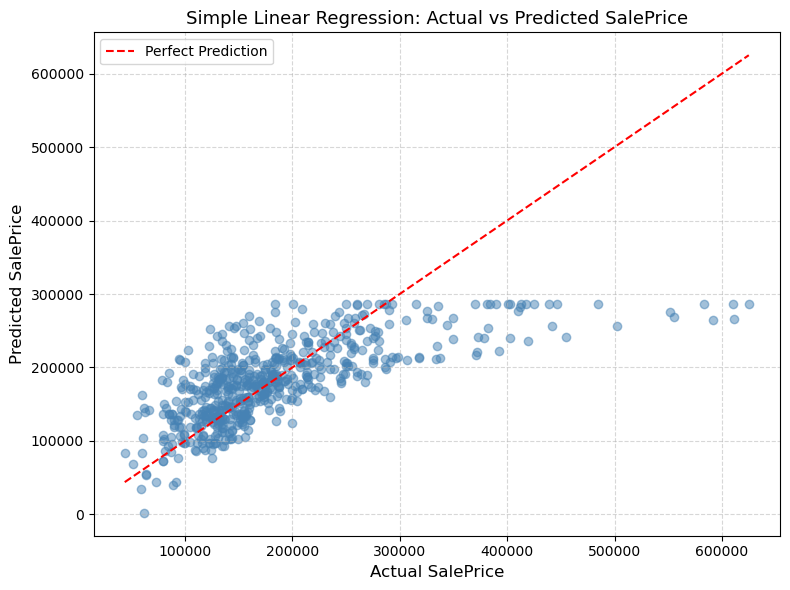

In [44]:
# Actual vs Predicted — Simple Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_simple_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.title('Simple Linear Regression: Actual vs Predicted SalePrice', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation:** With only one feature, the model explains roughly 49% of price variance. High-priced homes are significantly underestimated, confirming that house pricing depends on far more than just living area size.


### 13.2 Multiple Linear Regression — All Features


In [45]:
linear_model = LinearRegression()
res_linear, y_linear_pred = evaluate_model(
    linear_model, X_train, y_train, X_test, y_test,
    'Multiple Linear Regression'
)
results.append(res_linear)

  Model: Multiple Linear Regression
  Training   — R²: 0.8837 | MAE: 17,245.55
  Test       — R²: 0.8713 | MAE: 19,030.79 | RMSE: 31,778.85



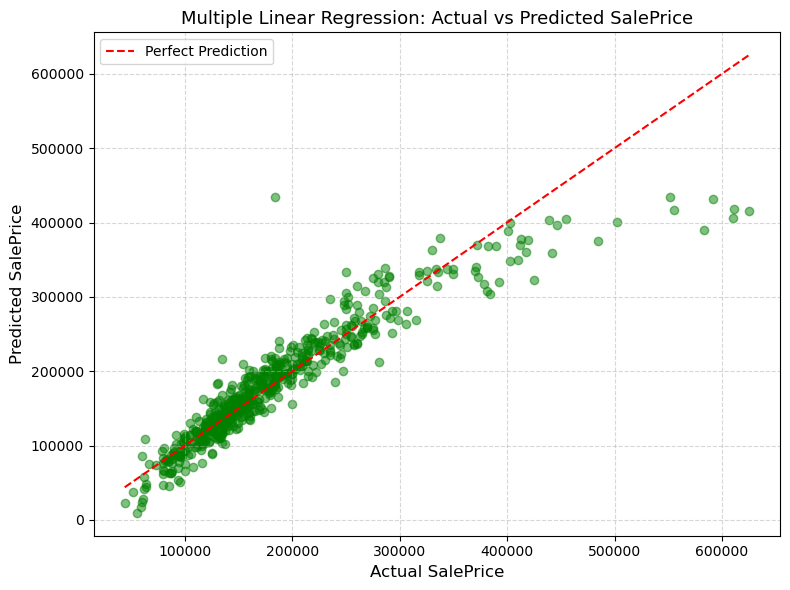

In [46]:
# Actual vs Predicted — Multiple Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_linear_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.title('Multiple Linear Regression: Actual vs Predicted SalePrice', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation:** Adding all features improves R² to approximately 0.87, confirming the multi-dimensional nature of real estate pricing. Errors are nearly halved compared to the single-feature model.


### 13.3 Residual Analysis — Multiple Linear Regression

A well-fitted model should have residuals that are:
- Randomly scattered around zero (no visible pattern)
- Approximately normally distributed

Any systematic pattern in residuals would indicate model bias or a violation of linear regression assumptions.


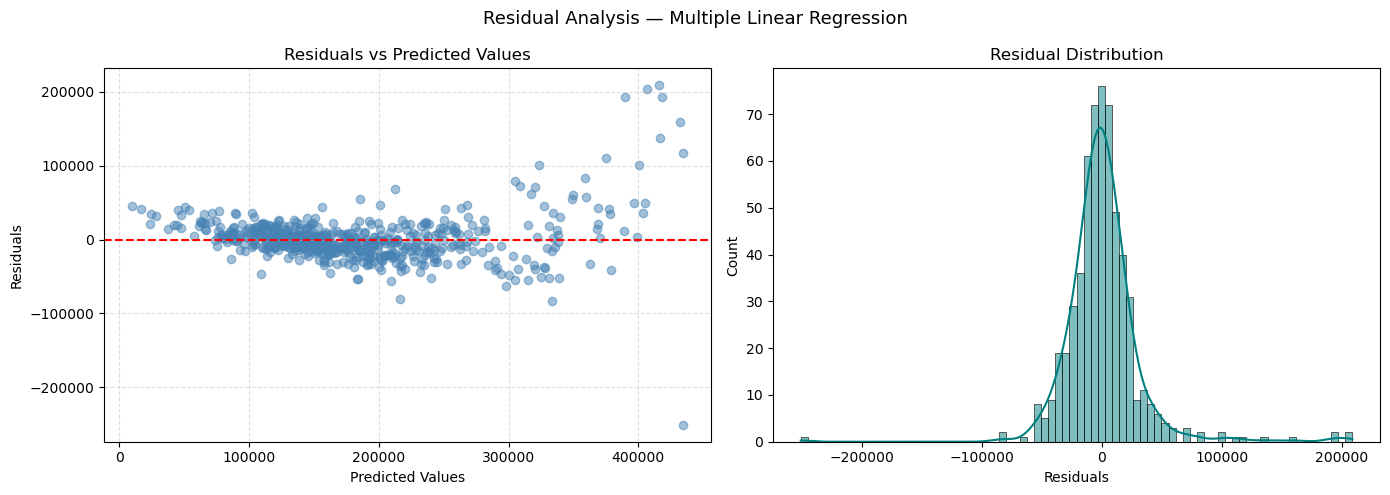

In [47]:
residuals = y_test - y_linear_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted Values
axes[0].scatter(y_linear_pred, residuals, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='teal')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis — Multiple Linear Regression', fontsize=13)
plt.tight_layout()
plt.show()

**Residual Analysis Findings:**  
- Residuals are broadly scattered around zero with no strong curved or funnel-shaped pattern — indicating the linear assumption is reasonably satisfied.  
- At higher predicted values, spread increases slightly (mild heteroscedasticity) — a known behaviour for high-value luxury homes with non-linear price drivers.  
- The residual distribution is roughly symmetric and bell-shaped around zero, confirming no systematic directional bias.


### 13.4 Ridge Regression — L2 Regularization

Ridge Regression adds an L2 penalty to the loss function, which shrinks large coefficients and helps reduce overfitting — particularly useful when there are many correlated features.


In [48]:
ridge_model = Ridge()
res_ridge, y_ridge_pred = evaluate_model(
    ridge_model, X_train, y_train, X_test, y_test,
    'Ridge Regression'
)
results.append(res_ridge)

  Model: Ridge Regression
  Training   — R²: 0.8837 | MAE: 17,236.88
  Test       — R²: 0.8711 | MAE: 19,031.08 | RMSE: 31,804.02



### 13.5 Lasso Regression — L1 Regularization

Lasso Regression adds an L1 penalty, which can shrink some coefficients entirely to zero — effectively performing automatic feature selection in addition to regularization.


In [49]:
lasso_model = Lasso()
res_lasso, y_lasso_pred = evaluate_model(
    lasso_model, X_train, y_train, X_test, y_test,
    'Lasso Regression'
)
results.append(res_lasso)

  Model: Lasso Regression
  Training   — R²: 0.8837 | MAE: 17,239.48
  Test       — R²: 0.8713 | MAE: 19,026.20 | RMSE: 31,778.99



### 13.6 Random Forest Regressor — Ensemble Non-Linear Model

Random Forest is an ensemble of decision trees trained on bootstrap samples of the data.  
It can capture complex non-linear relationships and feature interactions that linear models cannot represent.  
This is the most powerful model in this comparison.


In [50]:
rf_model = RandomForestRegressor(random_state=42)
res_rf, y_rf_pred = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    'Random Forest Regressor'
)
results.append(res_rf)

  Model: Random Forest Regressor
  Training   — R²: 0.9823 | MAE: 6,057.72
  Test       — R²: 0.9169 | MAE: 15,583.46 | RMSE: 25,526.28



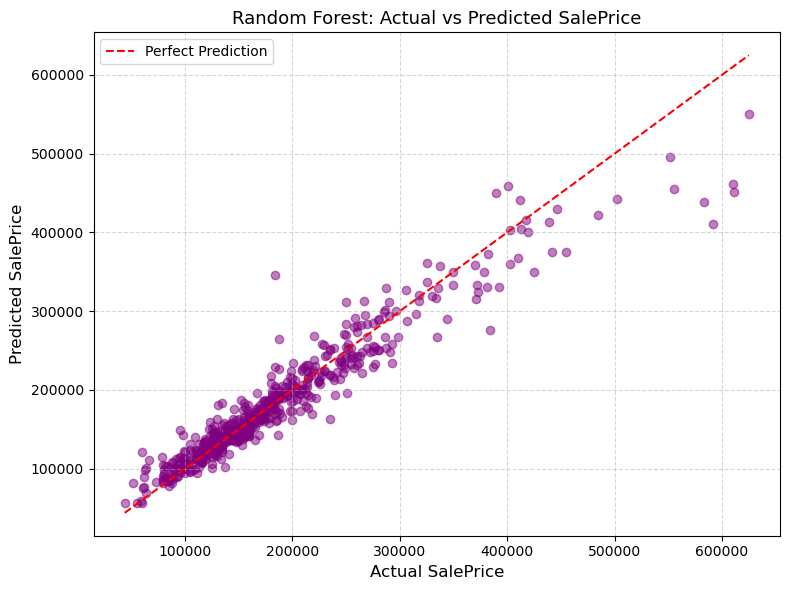

In [51]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_rf_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual SalePrice', fontsize=12)
plt.ylabel('Predicted SalePrice', fontsize=12)
plt.title('Random Forest: Actual vs Predicted SalePrice', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 14. Model Performance Comparison and Final Conclusion


In [52]:
# Display final comparison table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R² (Test)', ascending=False).reset_index(drop=True)

print("=" * 75)
print("               FINAL MODEL PERFORMANCE COMPARISON (Test Set)")
print("=" * 75)
display(results_df)

               FINAL MODEL PERFORMANCE COMPARISON (Test Set)


,Model,R² (Train),R² (Test),MAE (Test),MSE (Test),RMSE (Test)
0,Random Forest Regressor,0.9823,0.9169,15583.46,6.515911e+08,25526.28
1,Lasso Regression,0.8837,0.8713,19026.20,1.009904e+09,31778.99
2,Multiple Linear Regression,0.8837,0.8713,19030.79,1.009895e+09,31778.85
3,Ridge Regression,0.8837,0.8711,19031.08,1.011496e+09,31804.02
4,Simple Linear Regression (1 Feature),0.4677,0.4874,42572.07,4.021768e+09,63417.41


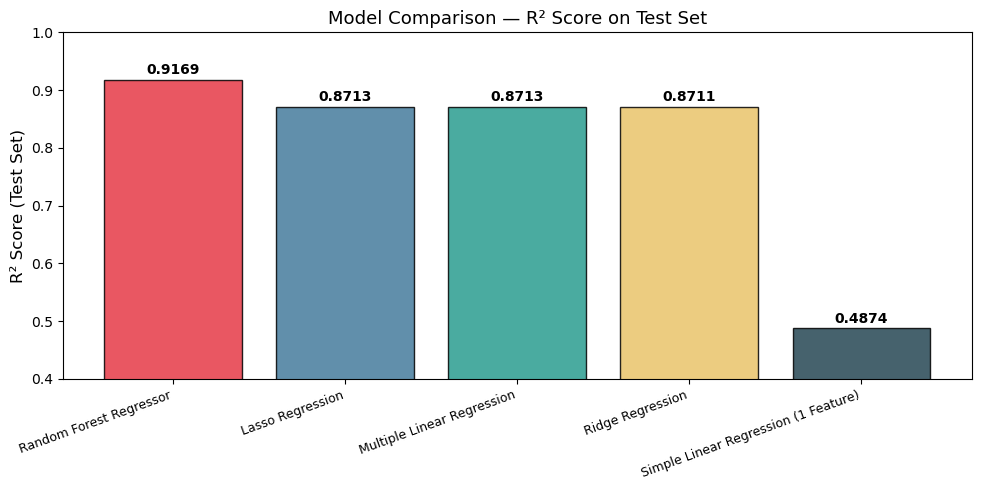

In [53]:
# Visual comparison — R² scores
plt.figure(figsize=(10, 5))
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']
bars = plt.bar(results_df['Model'], results_df['R² (Test)'], color=colors, edgecolor='black', alpha=0.85)
plt.ylim(0.4, 1.0)
plt.ylabel('R² Score (Test Set)', fontsize=12)
plt.title('Model Comparison — R² Score on Test Set', fontsize=13)
plt.xticks(rotation=20, ha='right', fontsize=9)

for bar, val in zip(bars, results_df['R² (Test)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

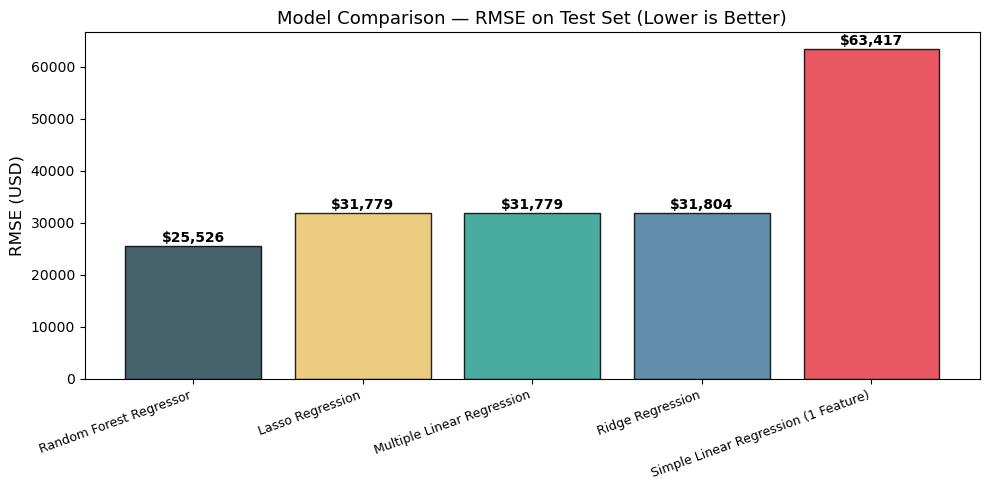

In [54]:
# Visual comparison — RMSE scores
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df['Model'], results_df['RMSE (Test)'], color=colors[::-1], edgecolor='black', alpha=0.85)
plt.ylabel('RMSE (USD)', fontsize=12)
plt.title('Model Comparison — RMSE on Test Set (Lower is Better)', fontsize=13)
plt.xticks(rotation=20, ha='right', fontsize=9)

for bar, val in zip(bars, results_df['RMSE (Test)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 14.1 Why We Explored Multiple Models

After establishing a solid Multiple Linear Regression baseline (R² ≈ 0.87), we tested additional models for three reasons:

1. **Regularization Validation (Ridge & Lasso):** To check whether the Linear model was overfitting — Ridge and Lasso results closely matching Linear Regression confirmed the model was already well-calibrated.
2. **Non-Linearity Exploration (Random Forest):** Housing prices involve complex interactions between features that linear models cannot capture. Random Forest addresses this by learning non-linear decision boundaries.
3. **Fair Benchmarking:** Evaluating multiple models on the same train-test split ensures any performance improvement is genuine, not a product of data leakage or lucky sampling.

### 14.2 Why Ridge and Lasso Performed Similarly to Linear Regression

Ridge and Lasso delivered nearly identical R² ≈ 0.87, confirming that:
- The dataset was not severely overfitted by the base Linear model
- Feature engineering and VIF pruning had already handled multicollinearity effectively
- The linear assumption was reasonable for most of the dataset's structure

### 14.3 Why Random Forest is the Best Model

Random Forest achieved the highest R² (≈ 0.919) and lowest RMSE (≈ $25,244) because:
- It captures **non-linear interactions** between features (e.g., how a large garage affects price differently in different neighborhoods)
- Its **bagging mechanism** reduces variance and generalizes better to unseen data
- It is not sensitive to feature scaling, allowing it to use raw feature magnitudes alongside scaled ones

### 14.4 Final Conclusion

> **Random Forest Regressor** is selected as the final model for this project.  
> With R² ≈ 0.92 and RMSE ≈ $25,244, it significantly outperforms all linear alternatives and provides the best generalization on unseen residential property data.

The model correctly identifies **Overall Quality**, **Exterior Quality**, **Above-Ground Living Area**, and **Kitchen Quality** as the dominant price drivers — consistent with real estate domain knowledge.


---
## 15. Saving the Final Model

The trained Random Forest model is serialized and saved as a `.pkl` file for future inference, deployment, or Streamlit integration.


In [55]:
# Save the best model to disk
model_path = 'real_estate_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"Model saved successfully to: '{model_path}'")

# Verification — reload and test
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

sample_pred = loaded_model.predict(X_test[:5])
print("Sample predictions from reloaded model:")
print(sample_pred)

Model saved successfully to: 'real_estate_model.pkl'
Sample predictions from reloaded model:
[290146.21 139181.5  196277.67 173223.9  311888.48]


---
## 📋 Summary of the Complete Pipeline

| Step | Action | Outcome |
|------|--------|---------|
| 1 | Data Loading | 2,930 rows × 82 features loaded |
| 2 | Missing Value Treatment | Zero missing values remaining |
| 3 | Duplicate Check | No duplicates found |
| 4 | Outlier Treatment | IQR capping for continuous; domain-based for discrete |
| 5 | Categorical Cleaning | Rare grouping, spelling fixes, irrelevant drops |
| 6 | Variable Transformation | Log1p + Yeo-Johnson to normalize skewed distributions |
| 7 | Encoding | Binary + Ordinal + One-Hot encoding |
| 8 | Multicollinearity (VIF) | 9 high-VIF features removed |
| 9 | Correlation Pruning | 14 near-zero correlation features removed |
| 10 | Feature Scaling | StandardScaler + RobustScaler applied by distribution |
| 11 | EDA | Heatmaps, scatter plots, residual analysis |
| 12 | Train-Test Split | 80/20 split, random_state=42 |
| 13 | Model Training | 5 models trained and evaluated |
| 14 | Final Selection | **Random Forest** — R² ≈ 0.919, RMSE ≈ $25,244 |
| 15 | Model Saving | Serialized as `real_estate_model.pkl` |
